In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, SGDRegressor

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False


In [15]:
carDF = pd.read_csv('data/cars.csv', index_col='Unnamed: 0')
carDF

,speed,dist
1,4,2
2,4,10
3,7,4
4,7,22
5,8,16
6,9,10
7,10,18
8,10,26
9,10,34
10,11,17


In [16]:
x = carDF[['speed']].values
y = carDF[['dist']].values

In [4]:
x

array([[ 4],
       [ 4],
       [ 7],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [10],
       [10],
       [11],
       [11],
       [12],
       [12],
       [12],
       [12],
       [13],
       [13],
       [13],
       [13],
       [14],
       [14],
       [14],
       [14],
       [15],
       [15],
       [15],
       [16],
       [16],
       [17],
       [17],
       [17],
       [18],
       [18],
       [18],
       [18],
       [19],
       [19],
       [19],
       [20],
       [20],
       [20],
       [20],
       [20],
       [22],
       [23],
       [24],
       [24],
       [24],
       [24],
       [25]])

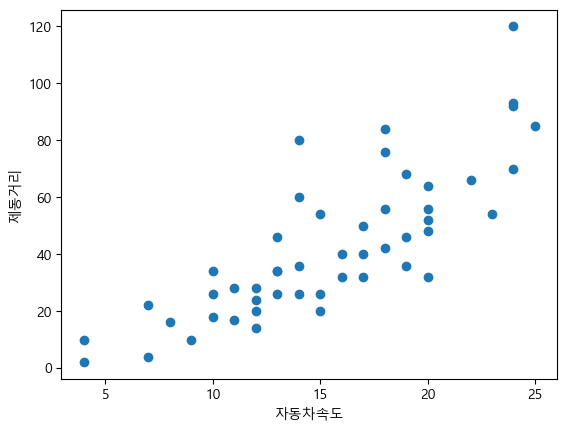

In [5]:
plt.xlabel('자동차속도')
plt.ylabel('제동거리')
plt.scatter(x,y)
plt.show()

### 회귀 공식을 이용

In [18]:
model = LinearRegression()
model.fit(x,y) # 반드시 특성 데이터, 라벨 행렬로 주어야 한다.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
print('기울기', model.coef_)
print('절편', model.intercept_)

기울기 [[3.93240876]]
절편 [-17.57909489]


In [8]:
10*float(model.coef_) + float(model.intercept_) #float를 사용해 [] 제거

C:\Users\Dell3571\AppData\Local\Temp\ipykernel_19352\982959124.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  10*float(model.coef_) + float(model.intercept_) #float를 사용해 [] 제거


21.744992700729917

In [9]:
model.predict([[10]]) #  必 반드시 행렬로, [[]]

array([[21.7449927]])

In [10]:
model.predict([[10],[15]]) # 

array([[21.7449927],
       [41.4070365]])

In [11]:
class MyLiner:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, x, y ):
        # 통계 공식
        self.coef_= np.sum((x-x.mean())*(y-y.mean()))/np.sum((x-x.mean()**2))
        self.intercept_ = y.mean() - self.coef_*x.mean()

    def predict(self, x):
        return self.coef_*x + self.intercept_
    
x = np.array([1,2,3,4,5])
y = np.array([3,5,7,9,11])
mymodel = MyLiner()
mymodel.fit(x,y)
print( mymodel.coef_, mymodel.intercept_)
print( mymodel.predict(7))

-0.6666666666666666 9.0
4.333333333333334


In [12]:
class Test:
    def __init__(self, a, b):
        self.a = a
        self.b = b

    def show(self):
        print('a=',self.a, 'b=',self.b)

tt = Test(10,20)
# tt.__init__(10,20)
tt.show()
print(tt.a,tt.b)

a= 10 b= 20
10 20


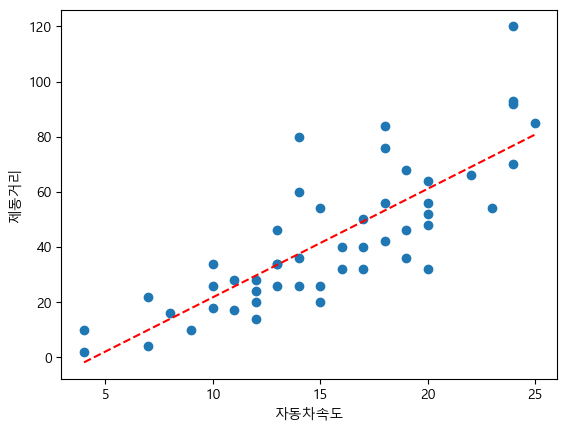

In [20]:
### Q) 실제 값(scatter), 예측값(선)
pred = model.predict(x)

plt.xlabel('자동차속도')
plt.ylabel('제동거리')
plt.scatter(x, y)
plt.plot(x, pred, 'r--')
plt.show()